# Employee Attrition Analysis 

## Phase 2: Data Understanding 

### Business Problem 

Employee turnover is expensive and impacts productivity, hiring costs, and employee morale.

The goal of this project is to identify patterns associated with employee attrition and provide recommendations that can help HR reduce employee turnover. 

In [30]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use('ggplot')

## Load the Dataset

In [25]:
df = pd.read_csv('../data/raw/WA_Fn-UseC_-HR-Employee-Attrition.csv')  

df.head()

,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,41,Yes,Travel_Rarely,1102,Sales,1,2,Life Sciences,1,1,...,1,80,0,8,0,1,6,4,0,5
1,49,No,Travel_Frequently,279,Research & Development,8,1,Life Sciences,1,2,...,4,80,1,10,3,3,10,7,1,7
2,37,Yes,Travel_Rarely,1373,Research & Development,2,2,Other,1,4,...,2,80,0,7,3,3,0,0,0,0
3,33,No,Travel_Frequently,1392,Research & Development,3,4,Life Sciences,1,5,...,3,80,0,8,3,3,8,7,3,0
4,27,No,Travel_Rarely,591,Research & Development,2,1,Medical,1,7,...,4,80,1,6,3,3,2,2,2,2


In [31]:
rows, cols = df.shape

print(f"Employees: {rows}") 
print(f"Variables: {cols}")

Employees: 1470
Variables: 35


## How many employees are there? How many variables?

The dataset contains 1470 employees and 35 variables. The target variable is 'Attrition', which indicates whether an employee has left the company or not. The dataset includes various features related to employee demographics, job satisfaction, performance, and other factors that may influence attrition.

In [27]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1470 entries, 0 to 1469
Data columns (total 35 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   Age                       1470 non-null   int64 
 1   Attrition                 1470 non-null   object
 2   BusinessTravel            1470 non-null   object
 3   DailyRate                 1470 non-null   int64 
 4   Department                1470 non-null   object
 5   DistanceFromHome          1470 non-null   int64 
 6   Education                 1470 non-null   int64 
 7   EducationField            1470 non-null   object
 8   EmployeeCount             1470 non-null   int64 
 9   EmployeeNumber            1470 non-null   int64 
 10  EnvironmentSatisfaction   1470 non-null   int64 
 11  Gender                    1470 non-null   object
 12  HourlyRate                1470 non-null   int64 
 13  JobInvolvement            1470 non-null   int64 
 14  JobLevel                

In [32]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
Age,1470.0,36.923810,9.135373,18.0,30.00,36.0,43.00,60.0
DailyRate,1470.0,802.485714,403.509100,102.0,465.00,802.0,1157.00,1499.0
DistanceFromHome,1470.0,9.192517,8.106864,1.0,2.00,7.0,14.00,29.0
Education,1470.0,2.912925,1.024165,1.0,2.00,3.0,4.00,5.0
EmployeeCount,1470.0,1.000000,0.000000,1.0,1.00,1.0,1.00,1.0
EmployeeNumber,1470.0,1024.865306,602.024335,1.0,491.25,1020.5,1555.75,2068.0
EnvironmentSatisfaction,1470.0,2.721769,1.093082,1.0,2.00,3.0,4.00,4.0
HourlyRate,1470.0,65.891156,20.329428,30.0,48.00,66.0,83.75,100.0
JobInvolvement,1470.0,2.729932,0.711561,1.0,2.00,3.0,3.00,4.0
JobLevel,1470.0,2.063946,1.106940,1.0,1.00,2.0,3.00,5.0


In [33]:
missing = (
    df.isnull()
    .sum()
    .sort_values(ascending=False)
)

missing

Age                         0
Attrition                   0
BusinessTravel              0
DailyRate                   0
Department                  0
DistanceFromHome            0
Education                   0
EducationField              0
EmployeeCount               0
EmployeeNumber              0
EnvironmentSatisfaction     0
Gender                      0
HourlyRate                  0
JobInvolvement              0
JobLevel                    0
JobRole                     0
JobSatisfaction             0
MaritalStatus               0
MonthlyIncome               0
MonthlyRate                 0
NumCompaniesWorked          0
Over18                      0
OverTime                    0
PercentSalaryHike           0
PerformanceRating           0
RelationshipSatisfaction    0
StandardHours               0
StockOptionLevel            0
TotalWorkingYears           0
TrainingTimesLastYear       0
WorkLifeBalance             0
YearsAtCompany              0
YearsInCurrentRole          0
YearsSince

In [34]:
attrition_counts = df['Attrition'].value_counts()

attrition_counts

Attrition
No     1233
Yes     237
Name: count, dtype: int64

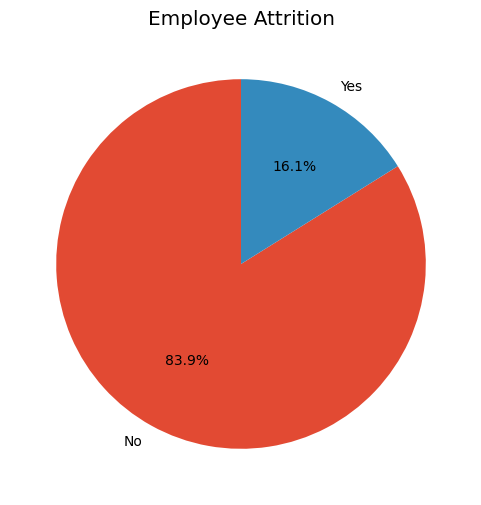

In [35]:
plt.figure(figsize=(6, 6))

plt.pie(
    attrition_counts, 
    labels=attrition_counts.index, 
    autopct='%1.1f%%', startangle=90
)

plt.title('Employee Attrition')

plt.show()

## Initial Observations

- The dataset contains 1,470 employees. 

- The dataset contains 35 variables. 

- There are 0 missing values, so imputation is not necessary. 

- Approximately 16% of employees left the company.

- The dataset appears to be imbalanced. 

In [ ]:
# Business Question 1: Which departments experience the highest employee attrition?

department_attrition = (
    pd.crosstab(
        df['Department'],  
        df['Attrition'], 
        normalize='index'
    ) * 100
)

department_attrition

Attrition,No,Yes
Department,,
Human Resources,80.952381,19.047619
Research & Development,86.160250,13.839750
Sales,79.372197,20.627803


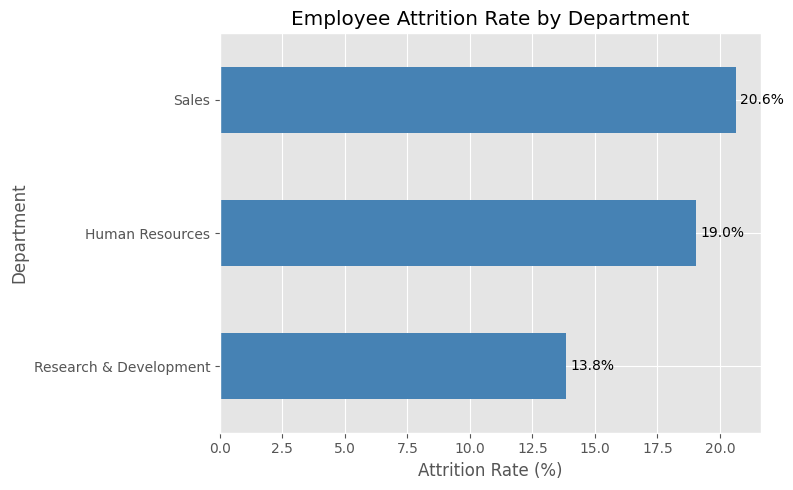

In [44]:
ax = department_attrition['Yes'].sort_values().plot(
    kind='barh',
    figsize=(8, 5),
    color="steelblue"
)

plt.title('Employee Attrition Rate by Department')
plt.xlabel('Attrition Rate (%)')
plt.ylabel('Department')

for container in ax.containers:
    ax.bar_label(container, fmt='%.1f%%', padding=3)

plt.tight_layout()
plt.show()

## Chart Observation 1

Employee turnover is not evenly distributed across the organization. Sales and Human Resources experience noticeably higher attrition rates than Research and Development, suggesting these departments may face unique retention challenges. 

Rather than implementing company-wide retention initiatives, HR should prioritize department-specific investigations in Sales and Human Resources. Those teams may benefit from targeted interviews, workload assessments, and compensation reviews. 

In [40]:
# Business Question 2: Does overtime contribute to employee attrition?

overtime_attrition = (
    pd.crosstab(
        df['OverTime'],
        df['Attrition'],
        normalize='index'
    ) * 100
)

overtime_attrition

Attrition,No,Yes
OverTime,,
No,89.563567,10.436433
Yes,69.471154,30.528846


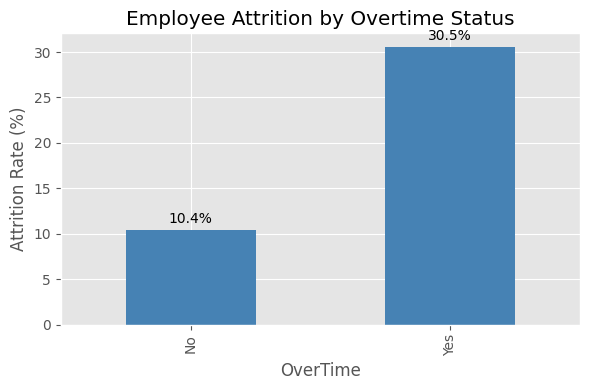

In [45]:
ax = overtime_attrition['Yes'].sort_values().plot(
    kind='bar',
    figsize=(6,4),
    color="steelblue"
)

plt.title('Employee Attrition by Overtime Status')
plt.ylabel('Attrition Rate (%)')

for container in ax.containers:
    ax.bar_label(container, fmt='%.1f%%', padding=3)

plt.tight_layout()
plt.show()

## Chart Observation 2

Employees who regularly work overtime leave the company at a substantially higher rate than employees who do not. 

Overtime should become a priority area for HR. The company could:

- Review overtime policies
- Monitor departments with consistently high overtime
- Survey employees about workload and work-life balance
- Explore staffing adjustments to reduce sustained overtime

In [42]:
# Business Question 3: Which job roles experience the highest turnover?

role_attrition = (
    pd.crosstab(
        df['JobRole'],  
        df['Attrition'],
        normalize='index'
    ) * 100
)

role_attrition 

Attrition,No,Yes
JobRole,,
Healthcare Representative,93.129771,6.870229
Human Resources,76.923077,23.076923
Laboratory Technician,76.061776,23.938224
Manager,95.098039,4.901961
Manufacturing Director,93.103448,6.896552
Research Director,97.500000,2.500000
Research Scientist,83.904110,16.095890
Sales Executive,82.515337,17.484663
Sales Representative,60.240964,39.759036


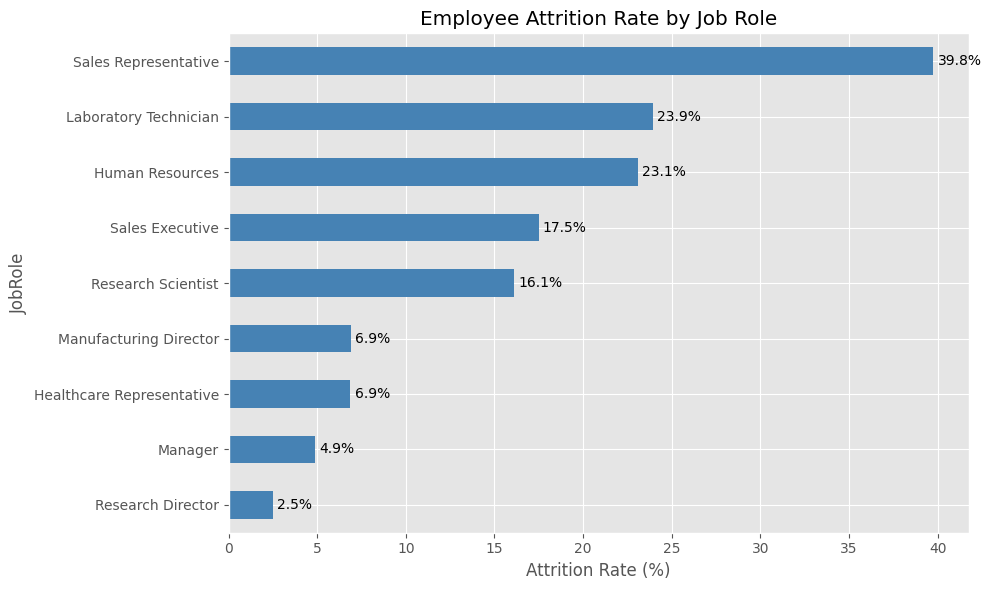

In [46]:
ax = role_attrition['Yes'].sort_values().plot(
    kind='barh',
    figsize=(10, 6), 
    color="steelblue"
)

plt.title('Employee Attrition Rate by Job Role')
plt.xlabel('Attrition Rate (%)')

for container in ax.containers:
    ax.bar_label(container, fmt='%.1f%%', padding=3)

plt.tight_layout()
plt.show()

## Chart Observation 3

Turnover varies considerably by job role. Front-line and customer-facing roles experience much higher attrition than leadership positions. 

Retention strategies should be tailored by role.

- Sales representatives may need improved onboarding, mentoring, or incentive structures. 

- Leadership roles exhibit much lower turnover, suggesting exsisting retention practices may already be effective for those positions.